In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('indian_roads_dataset.csv')

In [3]:
df.head()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10


In [4]:
df.shape

(20000, 24)

In [5]:
df.columns

Index(['accident_id', 'city', 'state', 'latitude', 'longitude', 'date', 'time',
       'hour', 'day_of_week', 'is_weekend', 'road_type', 'lanes',
       'traffic_signal', 'weather', 'visibility', 'temperature',
       'traffic_density', 'cause', 'accident_severity', 'vehicles_involved',
       'casualties', 'is_peak_hour', 'festival', 'risk_score'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   accident_id        20000 non-null  int64  
 1   city               20000 non-null  object 
 2   state              20000 non-null  object 
 3   latitude           20000 non-null  float64
 4   longitude          20000 non-null  float64
 5   date               20000 non-null  object 
 6   time               20000 non-null  object 
 7   hour               20000 non-null  int64  
 8   day_of_week        20000 non-null  object 
 9   is_weekend         20000 non-null  int64  
 10  road_type          20000 non-null  object 
 11  lanes              20000 non-null  int64  
 12  traffic_signal     20000 non-null  int64  
 13  weather            20000 non-null  object 
 14  visibility         20000 non-null  object 
 15  temperature        20000 non-null  int64  
 16  traffic_density    200

In [7]:
df.describe(include='all')

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
count,20000.000000,20000,20000,20000.000000,20000.000000,20000,20000,20000.000000,20000,20000.000000,...,20000,20000.000000,20000,20000,20000,20000.000000,20000.000000,20000.000000,115,20000.000000
unique,NaN,8,7,NaN,NaN,1201,24,NaN,7,NaN,...,3,NaN,3,5,3,NaN,NaN,NaN,4,NaN
top,NaN,Chandigarh,Maharashtra,NaN,NaN,2022-11-03,2:00,NaN,Monday,NaN,...,low,NaN,low,distraction,minor,NaN,NaN,NaN,Holi,NaN
freq,NaN,2577,5009,NaN,NaN,30,888,NaN,2966,NaN,...,9987,NaN,7067,4026,11025,NaN,NaN,NaN,38,NaN
mean,9999.500000,NaN,NaN,20.389207,78.173330,NaN,NaN,11.487200,NaN,0.286150,...,NaN,27.579600,NaN,NaN,NaN,2.992000,1.726450,0.247400,NaN,0.437585
std,5773.647028,NaN,NaN,6.165791,4.485967,NaN,NaN,6.945563,NaN,0.451972,...,NaN,7.454746,NaN,NaN,NaN,1.415534,1.489104,0.431512,NaN,0.218130
min,0.000000,NaN,NaN,12.800172,72.700017,NaN,NaN,0.000000,NaN,0.000000,...,NaN,15.000000,NaN,NaN,NaN,1.000000,0.000000,0.000000,NaN,0.100000
25%,4999.750000,NaN,NaN,13.198653,73.997979,NaN,NaN,5.000000,NaN,0.000000,...,NaN,21.000000,NaN,NaN,NaN,2.000000,1.000000,0.000000,NaN,0.250000
50%,9999.500000,NaN,NaN,18.812008,77.297000,NaN,NaN,12.000000,NaN,0.000000,...,NaN,28.000000,NaN,NaN,NaN,3.000000,1.000000,0.000000,NaN,0.450000
75%,14999.250000,NaN,NaN,28.402467,80.111089,NaN,NaN,18.000000,NaN,1.000000,...,NaN,34.000000,NaN,NaN,NaN,4.000000,3.000000,0.000000,NaN,0.600000


- Dataset has 20000 rows and 24 columns.
- There are both numerical and categorical features.
- Target variable is risk_score.

In [9]:
missing = df.isnull().sum()
missing

accident_id              0
city                     0
state                    0
latitude                 0
longitude                0
date                     0
time                     0
hour                     0
day_of_week              0
is_weekend               0
road_type                0
lanes                    0
traffic_signal           0
weather                  0
visibility               0
temperature              0
traffic_density          0
cause                    0
accident_severity        0
vehicles_involved        0
casualties               0
is_peak_hour             0
festival             19885
risk_score               0
dtype: int64

In [10]:
missing_percent = (df.isnull().sum()/len(df))*100
missing_percent.sort_values(ascending=False)

festival             99.425
accident_id           0.000
state                 0.000
city                  0.000
longitude             0.000
date                  0.000
time                  0.000
latitude              0.000
hour                  0.000
day_of_week           0.000
road_type             0.000
is_weekend            0.000
traffic_signal        0.000
weather               0.000
visibility            0.000
lanes                 0.000
temperature           0.000
traffic_density       0.000
accident_severity     0.000
cause                 0.000
vehicles_involved     0.000
casualties            0.000
is_peak_hour          0.000
risk_score            0.000
dtype: float64

- Festival contains 99.425% missing values.

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.dtypes

accident_id            int64
city                  object
state                 object
latitude             float64
longitude            float64
date                  object
time                  object
hour                   int64
day_of_week           object
is_weekend             int64
road_type             object
lanes                  int64
traffic_signal         int64
weather               object
visibility            object
temperature            int64
traffic_density       object
cause                 object
accident_severity     object
vehicles_involved      int64
casualties             int64
is_peak_hour           int64
festival              object
risk_score           float64
dtype: object

In [13]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

accident_id: 20000
city: 8
state: 7
latitude: 19907
longitude: 19927
date: 1201
time: 24
hour: 24
day_of_week: 7
is_weekend: 2
road_type: 3
lanes: 6
traffic_signal: 2
weather: 3
visibility: 3
temperature: 26
traffic_density: 3
cause: 5
accident_severity: 3
vehicles_involved: 5
casualties: 6
is_peak_hour: 2
festival: 4
risk_score: 18


In [14]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
['accident_id', 'latitude', 'longitude', 'hour', 'is_weekend', 'lanes', 'traffic_signal', 'temperature', 'vehicles_involved', 'casualties', 'is_peak_hour', 'risk_score']

Categorical Columns:
['city', 'state', 'date', 'time', 'day_of_week', 'road_type', 'weather', 'visibility', 'traffic_density', 'cause', 'accident_severity', 'festival']


The dataset contains 12 numerical and 12 categorical columns. However, not all of these are suitable for model training. Since the objective is to predict the safest route before a journey begins, only features that can be obtained at runtime (such as weather, road type, time, and temperature) will be considered for the final model. Columns like accident_severity, cause, vehicles_involved, and casualties are excluded from modeling because they represent information available only after an accident has occurred.

In [15]:
df["risk_score"].describe()

count    20000.000000
mean         0.437585
std          0.218130
min          0.100000
25%          0.250000
50%          0.450000
75%          0.600000
max          1.000000
Name: risk_score, dtype: float64

The target variable risk_score ranges from 0.10 to 1.00, with an average value of 0.438. The median (0.45) is very close to the mean, indicating that the distribution is approximately balanced without significant skewness. The interquartile range (0.25–0.60) shows that most observations fall within the low to moderate risk range. Since risk_score is a continuous numerical variable, it is appropriate to treat this as a regression problem

In [16]:
print(df["risk_score"].nunique())
print(sorted(df["risk_score"].unique()))

18
[np.float64(0.1), np.float64(0.2), np.float64(0.25), np.float64(0.3), np.float64(0.35), np.float64(0.4), np.float64(0.45), np.float64(0.5), np.float64(0.55), np.float64(0.6), np.float64(0.65), np.float64(0.7), np.float64(0.75), np.float64(0.8), np.float64(0.85), np.float64(0.9), np.float64(0.95), np.float64(1.0)]


The dataset contains 18 unique risk score values ranging from 0.10 to 1.00. This suggests that the target variable is an engineered risk index rather than a naturally measured continuous value. Nevertheless, it remains suitable as the target variable for regression since the application's objective is to predict a route risk score.

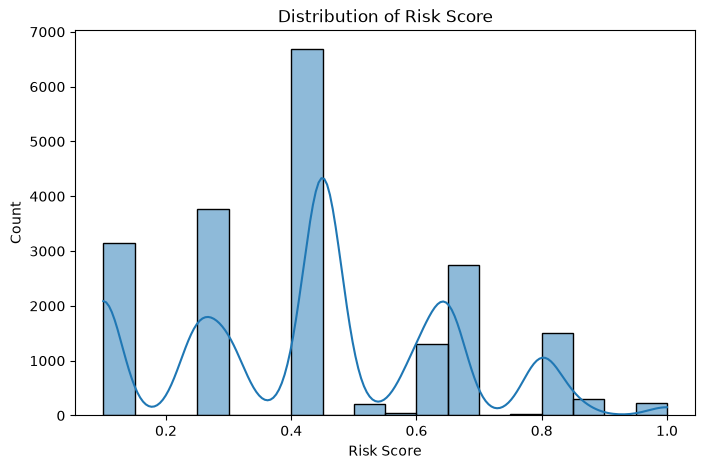

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df["risk_score"], bins=18, kde=True)
plt.title("Distribution of Risk Score")
plt.xlabel("Risk Score")
plt.ylabel("Count")
plt.show()

The distribution of risk_score is multimodal, with several peaks corresponding to the 18 predefined risk score values present in the dataset. The majority of observations lie around the 0.40–0.45 range, while very high-risk values (0.95–1.00) occur less frequently. Although the target variable is not normally distributed, it is reasonably balanced and suitable for training a regression model to predict route risk scores.
The risk_score appears to be an engineered risk index with discrete values rather than a directly measured continuous variable. In this project, it is treated as a Route Risk Index, which aligns with the application's objective of ranking multiple routes based on their predicted safety.

In [18]:
df["weather"].value_counts()

weather
clear    6690
rain     6677
fog      6633
Name: count, dtype: int64

In [19]:
df.groupby("weather")["risk_score"].mean()

weather
clear    0.236876
fog      0.589123
rain     0.488146
Name: risk_score, dtype: float64

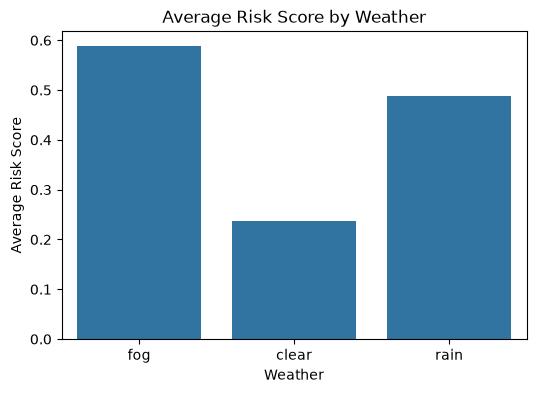

In [21]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=df,
    x="weather",
    y="risk_score",
    estimator="mean",
    errorbar=None
)

plt.title("Average Risk Score by Weather")
plt.xlabel("Weather")
plt.ylabel("Average Risk Score")

plt.show()

The dataset is well balanced across all three weather conditions, with nearly equal numbers of records for clear, rain, and fog. This balanced distribution reduces the possibility of bias toward any particular weather condition during model training.
Weather has a significant impact on the predicted risk score. Foggy conditions are associated with the highest average risk (0.589), followed by rainy conditions (0.488), while clear weather has the lowest average risk (0.237). This trend aligns with real-world driving conditions, where reduced visibility and wet roads increase the likelihood of accidents. Therefore, weather is expected to be an important predictor in the regression model.

In [22]:
df["visibility"].value_counts()

visibility
low       9987
high      6690
medium    3323
Name: count, dtype: int64

In [23]:
df.groupby("visibility")["risk_score"].mean()

visibility
high      0.236876
low       0.589176
medium    0.386067
Name: risk_score, dtype: float64

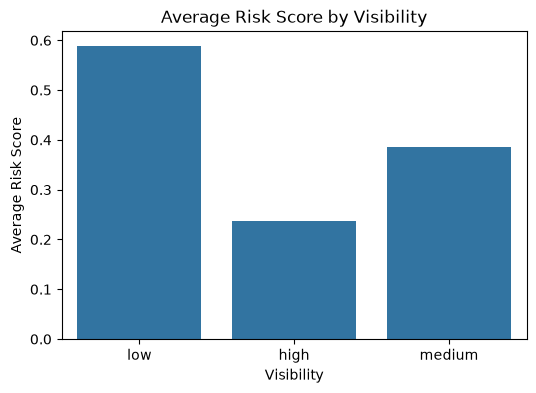

In [25]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=df,
    x="visibility",
    y="risk_score",
    estimator="mean",
    errorbar=None
)

plt.title("Average Risk Score by Visibility")
plt.xlabel("Visibility")
plt.ylabel("Average Risk Score")

plt.show()

The dataset contains three visibility levels: low, medium, and high. Low visibility is the most common condition, accounting for nearly half of the records, while medium visibility has the fewest observations.
Visibility has a strong relationship with the risk score. Low visibility is associated with the highest average risk (0.589), while high visibility has the lowest average risk (0.237). This follows real-world driving conditions, where poor visibility due to fog, rain, or other environmental factors increases accident risk. Hence, visibility is an important feature for predicting route safety.

In [26]:
df["road_type"].value_counts()

road_type
urban      6745
rural      6639
highway    6616
Name: count, dtype: int64

In [27]:
df.groupby("road_type")["risk_score"].mean()

road_type
highway    0.437455
rural      0.434659
urban      0.440593
Name: risk_score, dtype: float64

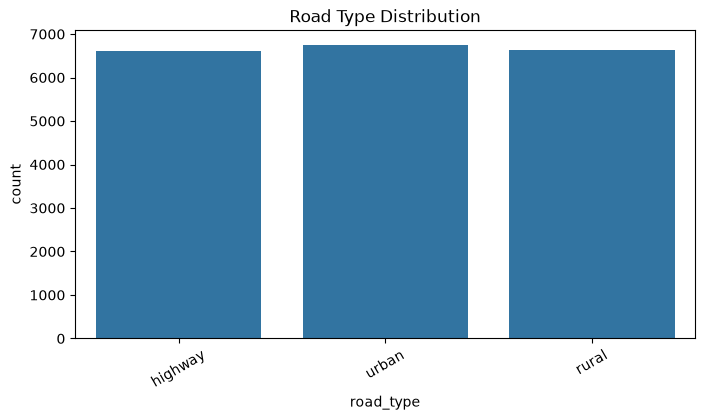

In [28]:
plt.figure(figsize=(8,4))

sns.countplot(data=df, x="road_type")

plt.title("Road Type Distribution")
plt.xticks(rotation=30)

plt.show()

The dataset is well balanced across the three road types (urban, rural, and highway), with each category containing approximately one-third of the total records. This balanced distribution helps prevent the model from becoming biased toward a particular road type.
The average risk scores across different road types are almost identical, ranging from 0.435 to 0.441. This suggests that road type alone does not have a strong influence on the risk score in the current dataset. Its contribution may become more meaningful when combined with other features such as weather, visibility, and time of travel.

In [29]:
df["temperature"].describe()

count    20000.000000
mean        27.579600
std          7.454746
min         15.000000
25%         21.000000
50%         28.000000
75%         34.000000
max         40.000000
Name: temperature, dtype: float64

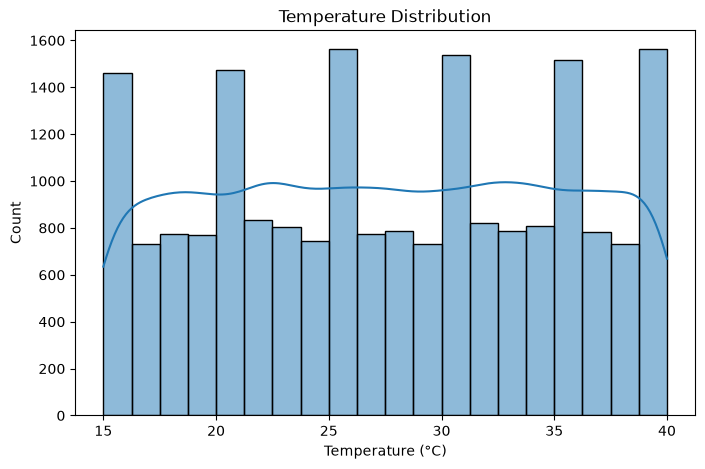

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(df["temperature"], bins=20, kde=True)

plt.title("Temperature Distribution")

plt.xlabel("Temperature (°C)")

plt.show()

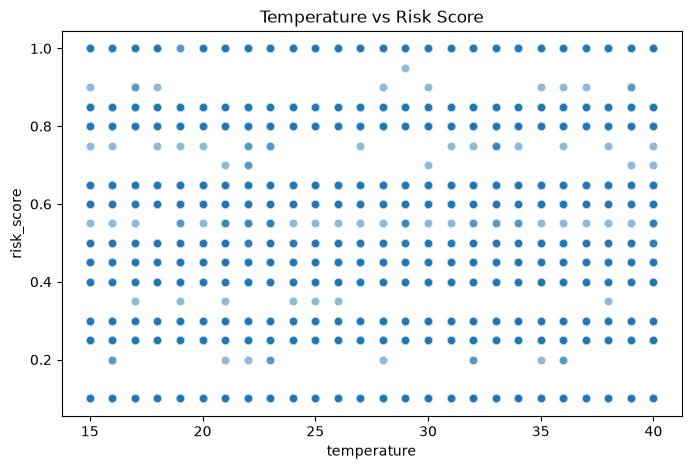

In [31]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="temperature",
    y="risk_score",
    alpha=0.5
)

plt.title("Temperature vs Risk Score")

plt.show()

- The temperature values range from 15°C to 40°C, with an average temperature of approximately 27.6°C. The mean and median are very close, indicating that the temperature values are fairly evenly distributed across the dataset.
- The temperature distribution appears to be fairly uniform, with observations spread across the entire range from 15°C to 40°C. There is no noticeable skewness or concentration around a particular temperature.
- The scatter plot does not reveal any clear relationship between temperature and the risk score. Similar risk levels are observed across the entire temperature range, suggesting that temperature alone is not a strong predictor of route risk. However, it may still contribute when combined with other contextual features such as weather and visibility.

In [32]:
df["hour"].describe()

count    20000.000000
mean        11.487200
std          6.945563
min          0.000000
25%          5.000000
50%         12.000000
75%         18.000000
max         23.000000
Name: hour, dtype: float64

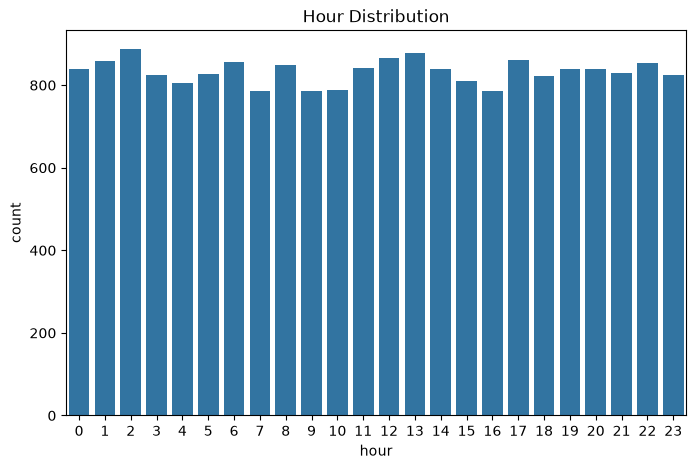

In [33]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="hour")

plt.title("Hour Distribution")

plt.show()

In [34]:
df.groupby("hour")["risk_score"].mean()

hour
0     0.355833
1     0.352328
2     0.341216
3     0.348119
4     0.355031
5     0.413241
6     0.390304
7     0.400191
8     0.608304
9     0.594911
10    0.609569
11    0.407967
12    0.397748
13    0.390945
14    0.393795
15    0.398397
16    0.379987
17    0.604994
18    0.613366
19    0.591429
20    0.391110
21    0.393494
22    0.383353
23    0.402788
Name: risk_score, dtype: float64

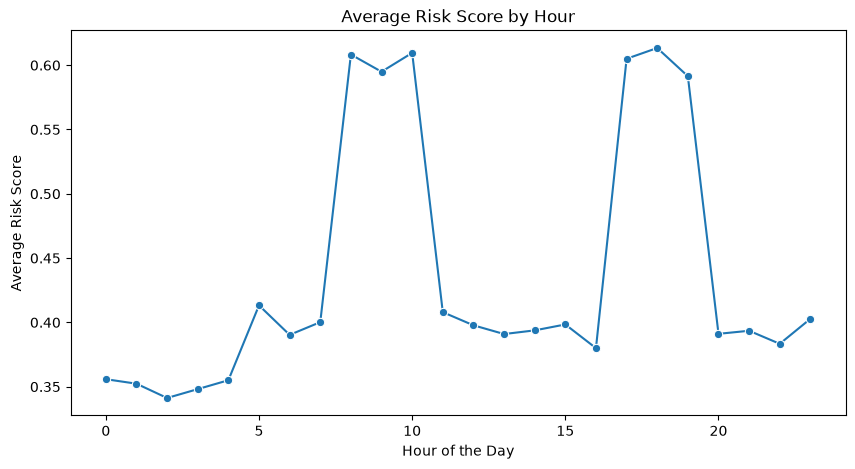

In [35]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=df,
    x="hour",
    y="risk_score",
    estimator="mean",
    errorbar=None,
    marker="o"
)

plt.title("Average Risk Score by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Average Risk Score")

plt.show()

- The hour feature covers all 24 hours of the day, ranging from 0 (midnight) to 23 (11 PM). The mean (11.49) and median (12) indicate that accident records are evenly distributed throughout the day.
- The distribution of accident records across the 24 hours is fairly uniform, with each hour containing a similar number of observations. This balanced distribution ensures that the model is not biased toward any specific time of the day.
- The average risk score varies significantly throughout the day. Two prominent peaks are observed during 8–10 AM and 5–7 PM, where the average risk exceeds 0.60. These time periods correspond to typical morning and evening rush hours, when traffic congestion is generally higher. During other hours, the average risk remains relatively lower (approximately 0.35–0.41). This indicates that the time of travel has a strong influence on route risk and is expected to be one of the most important predictors in the regression model.

In [36]:
df["is_peak_hour"].value_counts()

is_peak_hour
0    15052
1     4948
Name: count, dtype: int64

In [37]:
df.groupby("is_peak_hour")["risk_score"].mean()

is_peak_hour
0    0.382952
1    0.603779
Name: risk_score, dtype: float64

- Approximately 75% of the records correspond to non-peak hours, while the remaining 25% occur during peak traffic hours. Although the dataset contains fewer peak-hour records, both classes have sufficient observations for model training.
- The average risk score during peak hours (0.604) is significantly higher than during non-peak hours (0.383). This indicates that traffic congestion during peak travel periods substantially increases the predicted route risk. Therefore, is_peak_hour is expected to be one of the strongest predictors in the regression model.

In [38]:
df["day_of_week"].value_counts()

day_of_week
Monday       2966
Friday       2879
Tuesday      2871
Saturday     2867
Sunday       2856
Thursday     2835
Wednesday    2726
Name: count, dtype: int64

In [39]:
df.groupby("day_of_week")["risk_score"].mean().sort_values()

day_of_week
Wednesday    0.434464
Friday       0.434682
Monday       0.437070
Sunday       0.438638
Saturday     0.439309
Thursday     0.439330
Tuesday      0.439498
Name: risk_score, dtype: float64

- The accident records are evenly distributed across all seven days of the week, with each day containing approximately 2,700–3,000 observations. This balanced distribution ensures that no particular day dominates the dataset.
- The average risk score remains almost constant across all days of the week, ranging only from 0.434 to 0.439. The difference between the highest and lowest values is very small (approximately 0.005), suggesting that the day of the week has little influence on the predicted risk score in this dataset.

In [40]:
df["is_weekend"].value_counts()

is_weekend
0    14277
1     5723
Name: count, dtype: int64

In [41]:
df.groupby("is_weekend")["risk_score"].mean()

is_weekend
0    0.437028
1    0.438974
Name: risk_score, dtype: float64

- The majority of accident records (71.4%) occurred on weekdays, while 28.6% occurred on weekends. This distribution is expected since weekdays account for a larger portion of the week and generally experience higher traffic volumes.
- The average risk scores for weekdays (0.437) and weekends (0.439) are nearly identical. The difference is negligible, suggesting that whether a day is a weekend has little impact on the predicted risk score in this dataset.

In [42]:
df["festival"].value_counts()

festival
Holi        38
Eid         34
Diwali      31
New Year    12
Name: count, dtype: int64

In [43]:
df.groupby("festival")["risk_score"].mean()

festival
Diwali      0.588710
Eid         0.602941
Holi        0.521053
New Year    0.520833
Name: risk_score, dtype: float64

In [44]:
df["festival"].isnull().sum()

np.int64(19885)

In [45]:
df["festival"].unique()

array([nan, 'Holi', 'Diwali', 'Eid', 'New Year'], dtype=object)

In [46]:
festival_temp = df["festival"].fillna("No Festival")

festival_temp.value_counts()

festival
No Festival    19885
Holi              38
Eid               34
Diwali            31
New Year          12
Name: count, dtype: int64

In [47]:
df.assign(festival=festival_temp).groupby("festival")["risk_score"].agg(["count","mean"])

,count,mean
festival,,
Diwali,31,0.588710
Eid,34,0.602941
Holi,38,0.521053
New Year,12,0.520833
No Festival,19885,0.436857


In [48]:
df["lanes"].describe()

count    20000.000000
mean         3.493950
std          1.705406
min          1.000000
25%          2.000000
50%          4.000000
75%          5.000000
max          6.000000
Name: lanes, dtype: float64

In [49]:
df.groupby("lanes")["risk_score"].mean()

lanes
1    0.438631
2    0.438242
3    0.435468
4    0.439787
5    0.435445
6    0.437928
Name: risk_score, dtype: float64

- The number of lanes ranges from 1 to 6, with an average of approximately 3.5 lanes. Most roads in the dataset have between 2 and 5 lanes, indicating a good variation in road infrastructure.
- The average risk score remains nearly constant across different lane counts, varying only between 0.435 and 0.440. This suggests that the number of lanes alone has a negligible influence on the predicted risk score in this dataset. However, it may still contribute when combined with other contextual features such as weather or road type.

In [50]:
df["traffic_signal"].describe()

count    20000.000000
mean         0.499850
std          0.500012
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: traffic_signal, dtype: float64

In [51]:
df.groupby("traffic_signal")["risk_score"].mean()

traffic_signal
0    0.437189
1    0.437981
Name: risk_score, dtype: float64

- The traffic_signal feature is a binary variable, where 0 indicates the absence of a traffic signal and 1 indicates its presence. The mean value of 0.50 suggests that the dataset is almost perfectly balanced between roads with and without traffic signals.
- The average risk scores for roads with and without traffic signals are almost identical. This indicates that the presence of a traffic signal alone has minimal influence on the predicted risk score in the current dataset.

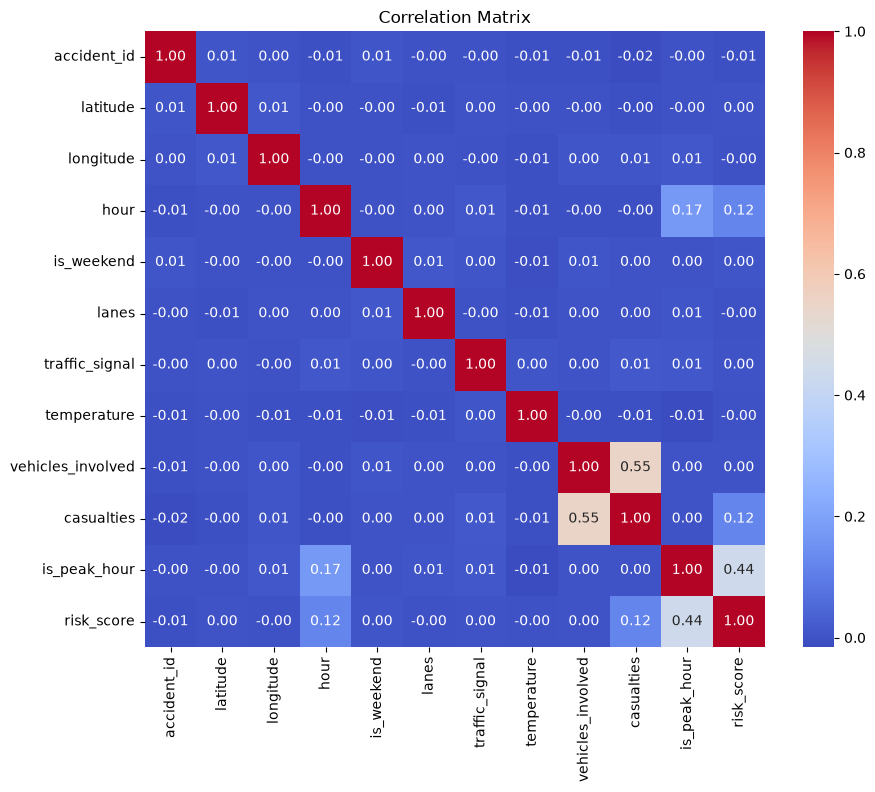

In [52]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

The correlation analysis indicates that is_peak_hour is the strongest numerical predictor of the target variable. Most remaining numerical features exhibit weak linear relationships with risk_score. Since several important predictors (such as weather, visibility, and road type) are categorical, correlation alone is insufficient for feature selection. Therefore, all runtime features will be further evaluated using tree-based feature importance during the modeling phase.

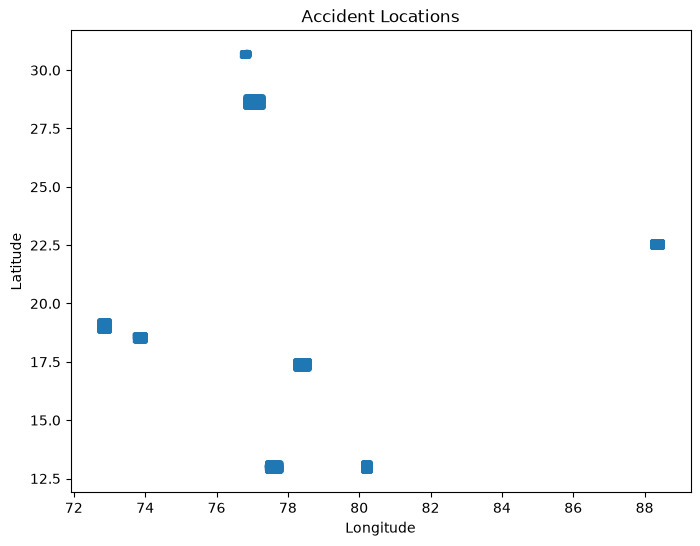

In [53]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["longitude"],
    df["latitude"],
    alpha=0.3,
    s=5
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Accident Locations")

plt.show()

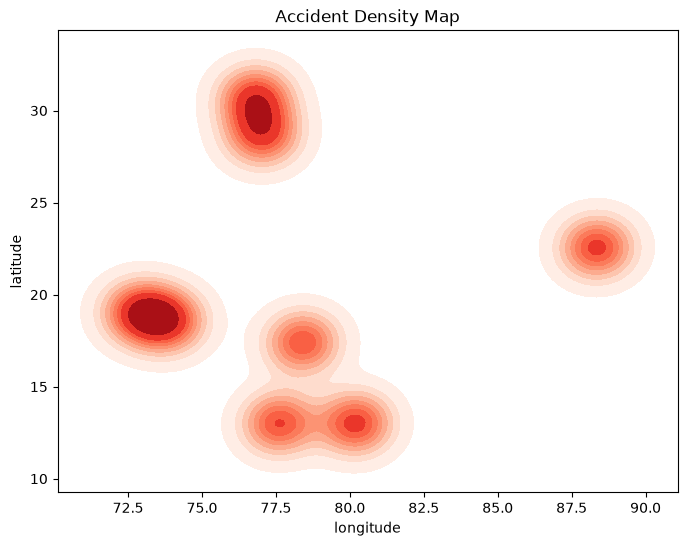

In [54]:
plt.figure(figsize=(8,6))

sns.kdeplot(
    data=df,
    x="longitude",
    y="latitude",
    fill=True,
    cmap="Reds"
)

plt.title("Accident Density Map")

plt.show()

In [55]:
city_counts = (
    df.groupby("city")
      .size()
      .sort_values(ascending=False)
)

city_counts.head(10)

city
Chandigarh    2577
Chennai       2575
Kolkata       2559
Pune          2517
Mumbai        2492
Bangalore     2438
Delhi         2433
Hyderabad     2409
dtype: int64

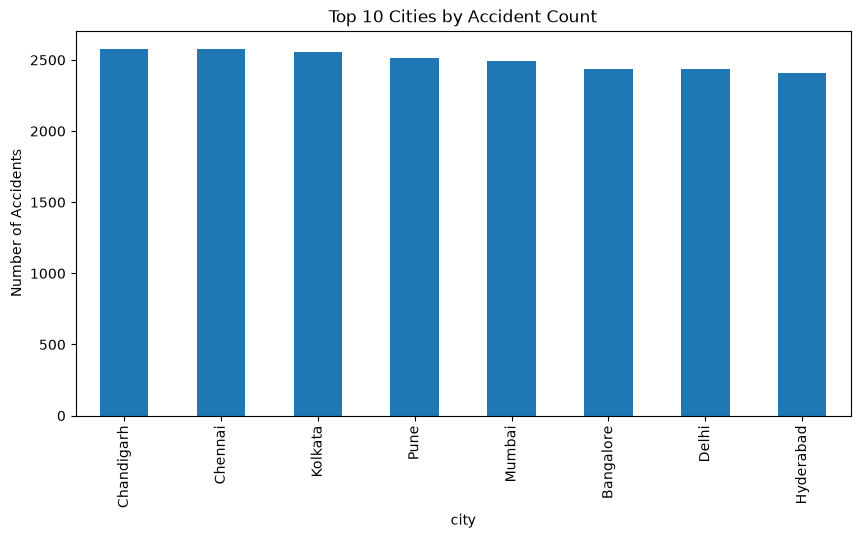

In [56]:
plt.figure(figsize=(10,5))

city_counts.head(10).plot(kind="bar")

plt.title("Top 10 Cities by Accident Count")

plt.ylabel("Number of Accidents")

plt.show()

In [57]:
city_risk = (
    df.groupby("city")["risk_score"]
      .mean()
      .sort_values(ascending=False)
)

city_risk.head(10)

city
Chandigarh    0.441618
Bangalore     0.440217
Hyderabad     0.439456
Chennai       0.437573
Delhi         0.437115
Pune          0.435836
Kolkata       0.434584
Mumbai        0.434350
Name: risk_score, dtype: float64

- The scatter plot shows that accident records are concentrated around a limited number of geographic regions rather than being uniformly distributed across India. These clusters correspond to major cities in the dataset, indicating that accidents occur more frequently in densely populated urban areas.
- The density map highlights distinct accident hotspots around several metropolitan regions. These hotspots represent areas with a high concentration of historical accidents and can be leveraged during route evaluation. If a candidate route passes through one or more hotspot regions, its overall safety score can be increased to reflect the higher historical accident risk.
- The dataset is relatively balanced across major Indian cities, with each city contributing approximately 2400–2600 accident records. This balanced representation ensures that the machine learning model is not biased toward a single geographic location.

In [58]:
df.isnull().sum().sort_values(ascending=False)

festival             19885
accident_id              0
state                    0
city                     0
longitude                0
date                     0
time                     0
latitude                 0
hour                     0
day_of_week              0
road_type                0
is_weekend               0
traffic_signal           0
weather                  0
visibility               0
lanes                    0
temperature              0
traffic_density          0
accident_severity        0
cause                    0
vehicles_involved        0
casualties               0
is_peak_hour             0
risk_score               0
dtype: int64

In [59]:
pd.crosstab(df["weather"], df["visibility"])

visibility,high,low,medium
weather,,,
clear,6690,0,0
fog,0,6633,0
rain,0,3354,3323


The relationship between weather and visibility is highly structured. All clear weather records have high visibility, while all fog records have low visibility. Rain is associated with either medium or low visibility. This indicates that visibility is strongly dependent on weather conditions rather than being an independently measured feature.

In [60]:
pd.crosstab(df["hour"], df["is_peak_hour"])

is_peak_hour,0,1
hour,,
0,840,0
1,859,0
2,888,0
3,824,0
4,805,0
5,827,0
6,856,0
7,786,0
8,0,849


- The is_peak_hour feature is completely derived from the hour feature. All records between 8–10 AM and 5–7 PM (17–19 hours) are labeled as peak hours, while all remaining hours are labeled as non-peak hours. Therefore, is_peak_hour is not an independent feature but rather a binary transformation of hour.

In [61]:
for col in ["weather", "visibility", "is_peak_hour", "road_type"]:
    print(f"\n===== {col} =====")
    print(df.groupby(col)["risk_score"].describe())


===== weather =====
          count      mean       std   min   25%   50%   75%   max
weather                                                          
clear    6690.0  0.236876  0.149048  0.10  0.10  0.25  0.30  0.75
fog      6633.0  0.589123  0.149599  0.45  0.45  0.60  0.65  1.00
rain     6677.0  0.488146  0.179730  0.25  0.40  0.45  0.65  1.00

===== visibility =====
             count      mean       std   min   25%   50%   75%   max
visibility                                                          
high        6690.0  0.236876  0.149048  0.10  0.10  0.25  0.30  0.75
low         9987.0  0.589176  0.149376  0.45  0.45  0.60  0.65  1.00
medium      3323.0  0.386067  0.147552  0.25  0.25  0.40  0.45  0.80

===== is_peak_hour =====
                count      mean       std   min   25%   50%   75%   max
is_peak_hour                                                           
0             15052.0  0.382952  0.195131  0.10  0.25  0.45  0.45  0.95
1              4948.0  0.603779  0.199